# Applying K-means Clustering to Biological Data

In this notebook, we'll apply k-means clustering to a real biological dataset — the Wisconsin Breast Cancer Dataset — to see how unsupervised machine learning can reveal structure in experimental data. We'll explore the need for data preprocessing and dimensionality reduction (using PCA) before clustering, then evaluate how well k-means recovers the true diagnostic labels.

### At the end of this notebook, you'll be able to:
* Enumerate examples of real-world applications of clustering
* Load and explore experimental datasets
* Recognize the need for data preprocessing and dimensionality reduction methods
* Identify a common dimensionality reduction method — Principal Component Analysis (PCA)
* Apply k-means clustering to realistic data
* Interpret results from clustering analysis

<hr>

## Importing Packages

> **Task**: Import `numpy` as `np`, `pandas` as `pd`, and `matplotlib.pyplot` as `plt`. Also import `KMeans` from `sklearn.cluster`.

In [1]:
# The usual suspects - np, pd and plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import kmeans clustering from sklearn
from sklearn.cluster import KMeans

# Import some extra stuff - datasets and PCA
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

# Seaborn is another useful package for plotting data
import seaborn as sns

# Import helper scripts
from kmeans_helper import *

## Load and Pre-process the Wisconsin Breast Cancer Dataset

This is one of the many toy datasets available in the `sklearn` package. We'll load it, apply some filtering, then use **Principal Component Analysis (PCA)** to reduce the data to two dimensions for visualization and clustering.

Learn more about the dataset at the [sklearn documentation](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset).

In [2]:
# Load the data
data = load_breast_cancer()

# Generate PCA data
brca_pca_data = clean_PCA_data(data)

99.10% Variance Explained


## Apply K-means Clustering

> **Task**: Apply K-means clustering on the PCA-transformed breast cancer data. Use `n_clusters=2` and assign the result to `brca_kmeans`. **Hint**: In the first notebook, we fit the variable `X`. Here, we're fitting `brca_pca_data`.

In [7]:
# Apply K-Means Clustering on BRCA PCA data
brca_kmeans = KMeans(
    n_clusters=2,
    random_state=1,
    max_iter=100).fit(brca_pca_data)

# Prepare hue labels as strings using data.target_names for consistency in legend
true_labels_str = np.array([data.target_names[label] for label in data.target])
kmeans_labels_str = np.array([data.target_names[label] for label in brca_kmeans.labels_])

## Assessing Clustering Results — Side-by-Side Plot
Below, we'll compare the true labels with the k-means assigned labels.

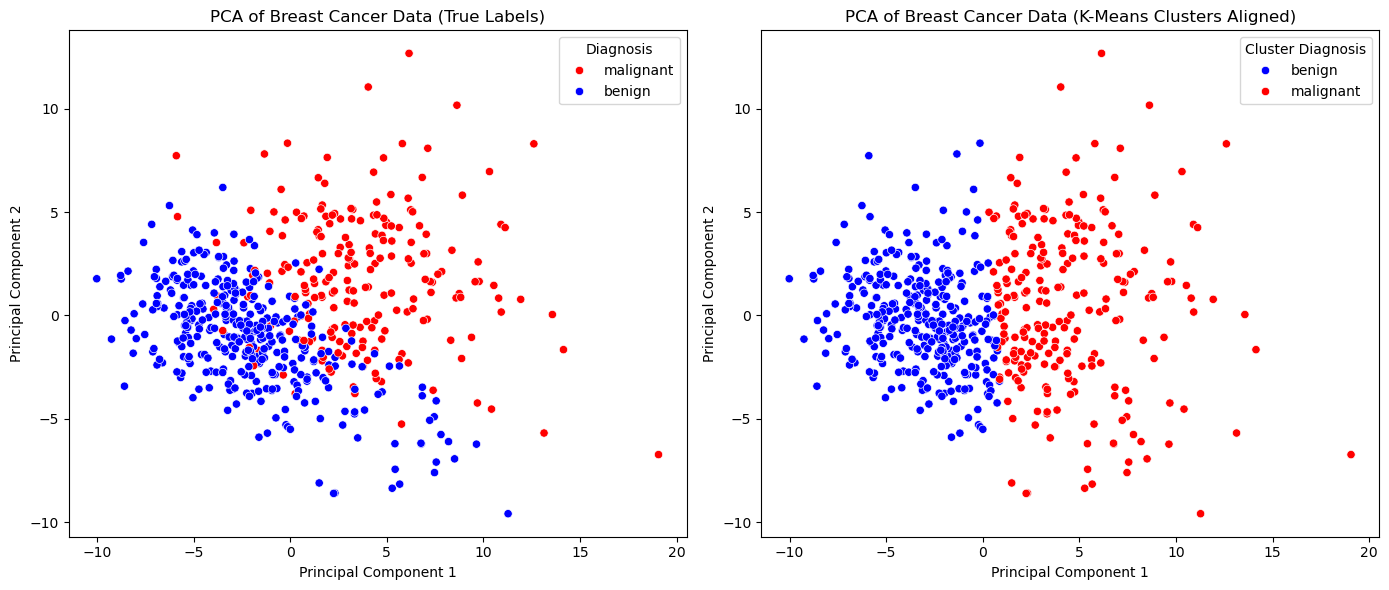

In [8]:
kmeans_plot(data,brca_pca_data,true_labels_str,kmeans_labels_str)

## Assessing Clustering Results — Contingency Table

We can use the `crosstab` function of `pandas` to compute a contingency table, which can tell us how well k-means did. After seeing the results, what looks like a problem here? How do you think you can fix this? (Just some questions for your exploration!)

In [18]:
contingency_table = pd.crosstab(true_labels_str, kmeans_labels_str)
print(contingency_table)

col_0      benign  malignant
row_0                       
benign        298         59
malignant      37        175


> **Task**: Using the contingency table printed above, calculate true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN), and then compute the overall accuracy.

In [ ]:
# Calculate TP, FP, TN, and FN from this data
tp = contingency_table.iloc[0,0]
tn = contingency_table.iloc[1,1]
fp = contingency_table.iloc[0,1]
fn = contingency_table.iloc[1,0]

accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f'Accuracy of this model: {accuracy*100:.2f}%')